<a href="https://colab.research.google.com/github/MahekLasi028/DSBDAL/blob/main/MINIPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import re
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [2]:
# 1. LOAD DATASET (Fixed with low_memory=False to remove DtypeWarning)
df_orig = pd.read_csv('/content/sample_data/data_science.csv', low_memory=False)


In [3]:
# 2. SELECT COLUMN & CLEAN (Using .copy() to avoid SettingWithCopyWarning)
df = df_orig[['tweet']].copy()
df.dropna(inplace=True)

In [4]:
# 3. GENERATE LABELS
def get_sentiment(text):
    score = TextBlob(str(text)).sentiment.polarity
    return 1 if score > 0 else 0

print("Labeling tweets... this may take a moment.")
df['label'] = df['tweet'].apply(get_sentiment)

Labeling tweets... this may take a moment.


In [5]:
# 4. PREPROCESSING
def clean_tweet(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()

df['clean_tweet'] = df['tweet'].apply(clean_tweet)

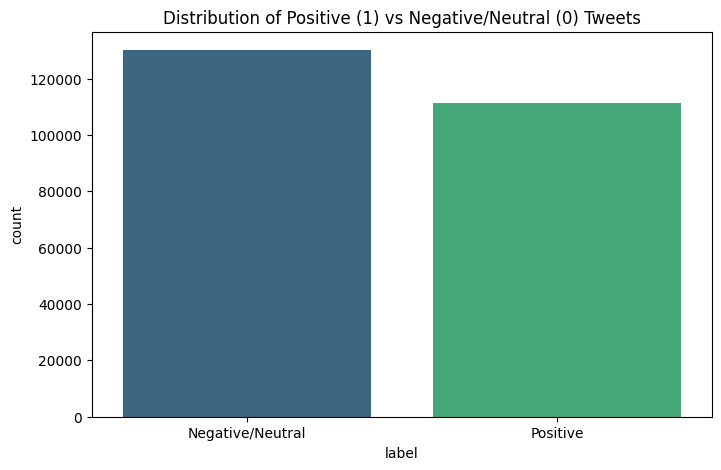

In [6]:
# --- PROJECT VISUALISATIONS ---
# A. Sentiment Distribution Bar Chart
plt.figure(figsize=(8, 5))

# Added hue='label' and legend=False to satisfy the new Seaborn requirement
sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)

plt.title('Distribution of Positive (1) vs Negative/Neutral (0) Tweets')
plt.xticks([0, 1], ['Negative/Neutral', 'Positive'])
plt.show()


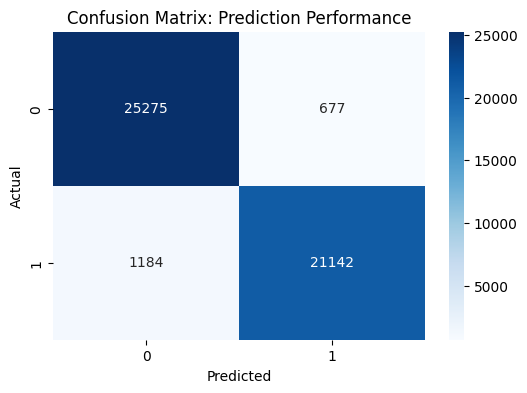

In [11]:
# 5 & 6. RE-GENERATE FEATURES AND TRAIN MODEL
# (This ensures X, y, y_test, and y_pred are all defined)

# Convert text to numbers
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['clean_tweet'])
y = df['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# --- B. CONFUSION MATRIX VISUALIZATION ---
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Prediction Performance')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


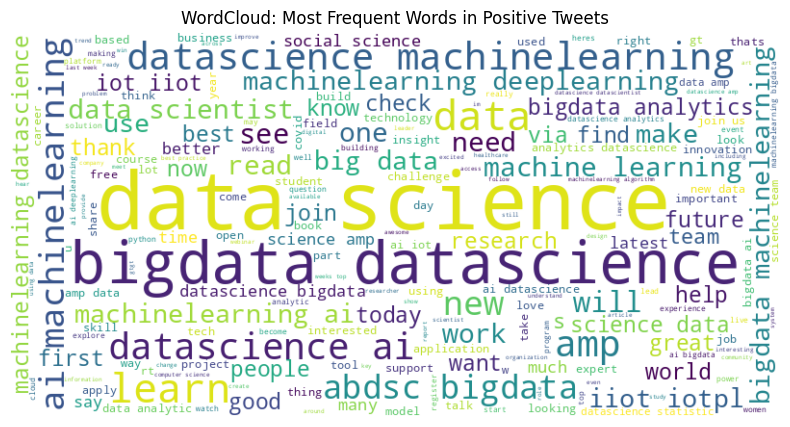

In [12]:
# C. WordCloud for Positive Tweets
pos_tweets = ' '.join(df[df['label'] == 1]['clean_tweet'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(pos_tweets)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: Most Frequent Words in Positive Tweets')
plt.show()

In [13]:
print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Final Model Accuracy: 96.15%
